# EmpaticaE4Stress 테스트 (subject_01 ~ subject_06)

이 노트북은 CATSA로 학습한 `TEMP_Grand_Final_Production_Model.pt`를 EmpaticaE4Stress 데이터에 적용합니다.

라벨 규칙:
- Non-stress(0): 맨 처음 Rest 3분
- Stress(1): Task 1, 2, 3, 4, 5
- 중간/마지막 Rest 구간: 평가에서 제외

참고:
- TEMP는 4Hz(초당 4샘플)로 가정합니다.
- Task 4는 "no time limit"이므로, 각 subject의 전체 길이에서 나머지 고정 길이를 빼서 역산합니다.

In [1]:
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

# 경로 설정
BASE_DIR = Path('/home/binghin2/Myproject')
MODEL_CANDIDATES = [
    BASE_DIR / 'Research' / 'CATSA' / 'Train' / 'Individual_data' / 'Temp' / 'Save_model' / 'TEMP_Grand_Final_Production_Model.pt',
]
MODEL_PATH = next((p for p in MODEL_CANDIDATES if p.exists()), MODEL_CANDIDATES[0])
DATA_ROOT = BASE_DIR / 'Dataset' / 'EmpaticaE4Stress' / 'Subjects'
SUBJECTS = [f'subject_{i:02d}' for i in range(1, 7)]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Model exists: {MODEL_PATH.exists()} -> {MODEL_PATH}')

Device: cuda
Model exists: True -> /home/binghin2/Myproject/Research/CATSA/Train/Individual_data/Temp/Save_model/TEMP_Grand_Final_Production_Model.pt


In [2]:
# 모델 정의 (CATSA 학습 아키텍처와 동일)
class Temp1DCNNTransformer(nn.Module):
    def __init__(self, hp: Dict):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=int(hp.get('transformer_heads', 4)),
            dim_feedforward=int(hp.get('transformer_ff_dim', 256)),
            dropout=float(hp.get('transformer_dropout', 0.2)),
            batch_first=True,
            activation='gelu',
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=int(hp.get('transformer_layers', 2)),
        )

        self.max_len = max(16, int(hp.get('window_size', 240)))
        self.pos_embedding = nn.Parameter(torch.zeros(1, self.max_len, 128))

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(float(hp.get('dropout_rate', 0.4))),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cnn(x)
        x = x.transpose(1, 2)  # [B, L, C]

        seq_len = x.size(1)
        if seq_len > self.pos_embedding.size(1):
            pos = torch.nn.functional.interpolate(
                self.pos_embedding.transpose(1, 2),
                size=seq_len,
                mode='linear',
                align_corners=False,
            ).transpose(1, 2)
        else:
            pos = self.pos_embedding[:, :seq_len, :]

        x = x + pos
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)


def load_temp_csv(path: Path) -> np.ndarray:
    # 0, 1행(헤더/설정값)을 제외하고 2행부터 실제 데이터를 로드합니다.
    df = pd.read_csv(path, header=None, skiprows=2)
    vals = df.squeeze('columns').to_numpy(dtype=np.float32)
    return vals

def build_protocol_labels(total_len: int, fs: int = 4) -> Tuple[np.ndarray, pd.DataFrame, int]:
    # 고정 길이(초)
    fixed_sec = {
        'rest0': 3 * 60,
        'task1': 10 * 60,
        'rest1': 2 * 60,
        'task2': 5 * 60,
        'rest2': 2 * 60,
        'task3': 3 * 60,
        'rest3': 2 * 60,
        'rest4': 2 * 60,
        'task5': 1 * 60,
        'rest5': 2 * 60,
    }
    fixed = {k: int(v * fs) for k, v in fixed_sec.items()}
    fixed_total = sum(fixed.values())
    task4 = total_len - fixed_total
    if task4 <= 0:
        raise ValueError(f'Total length {total_len/fs:.1f}s is too short for protocol (fixed {fixed_total/fs:.1f}s).')

    # 평가 라벨: 0=non-stress(초기 rest), 1=stress(task들), -1=평가 제외(rest)
    labels = np.full((total_len,), -1, dtype=np.int64)
    rows: List[Tuple[str, int, int, int]] = []

    segments = [
        ('rest0', fixed['rest0'], 0),
        ('task1', fixed['task1'], 1),
        ('rest1', fixed['rest1'], -1),
        ('task2', fixed['task2'], 1),
        ('rest2', fixed['rest2'], -1),
        ('task3', fixed['task3'], 1),
        ('rest3', fixed['rest3'], -1),
        ('task4', task4, 1),
        ('rest4', fixed['rest4'], -1),
        ('task5', fixed['task5'], 1),
        ('rest5', fixed['rest5'], -1),
    ]

    cur = 0
    for name, dur, lab in segments:
        end = min(cur + dur, total_len)
        if end > cur:
            labels[cur:end] = lab
            rows.append((name, cur, end, lab))
        cur = end
        if cur >= total_len:
            break

    seg_df = pd.DataFrame(rows, columns=['segment', 'start_sample', 'end_sample', 'label'])
    seg_df['start_sec'] = seg_df['start_sample'] / fs
    seg_df['end_sec'] = seg_df['end_sample'] / fs
    return labels, seg_df, int(task4 / fs)


def normalize_subject(hr: np.ndarray, labels: np.ndarray) -> Tuple[np.ndarray, float, float]:
    use_mask = labels >= 0
    if np.any(use_mask):
        mu = float(np.mean(hr[use_mask]))
        sigma = float(np.std(hr[use_mask])) + 1e-8
    else:
        mu = float(np.mean(hr))
        sigma = float(np.std(hr)) + 1e-8
    return (hr - mu) / sigma, mu, sigma


def sliding_windows_with_label(signal: np.ndarray, labels: np.ndarray, window_size: int, stride: int) -> Tuple[np.ndarray, np.ndarray]:
    x_chunks: List[np.ndarray] = []
    y_chunks: List[int] = []

    if len(signal) < window_size:
        return np.empty((0, 1, window_size), dtype=np.float32), np.empty((0,), dtype=np.int64)

    for i in range(0, len(signal) - window_size + 1, stride):
        w_sig = signal[i:i + window_size]
        w_lab = labels[i:i + window_size]
        uniq = np.unique(w_lab)

        # 윈도우 전체가 동일하고 유효 라벨(0/1)일 때만 평가에 사용
        if len(uniq) == 1 and uniq[0] in (0, 1):
            x_chunks.append(w_sig.astype(np.float32))
            y_chunks.append(int(uniq[0]))

    if len(x_chunks) == 0:
        return np.empty((0, 1, window_size), dtype=np.float32), np.empty((0,), dtype=np.int64)

    x = np.asarray(x_chunks, dtype=np.float32)[:, None, :]
    y = np.asarray(y_chunks, dtype=np.int64)
    return x, y

In [3]:
# 체크포인트 로드
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)

if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    model_state = ckpt['model_state_dict']
    hp = ckpt.get('hyperparameters', {})
else:
    # 혹시 state_dict만 저장된 경우 대비
    model_state = ckpt
    hp = {}

# 학습 기본값 보강 (TEMP 4Hz: 60초 윈도우=240, 10초 stride=40)
hp.setdefault('window_size', 240)
hp.setdefault('stride', 40)
hp.setdefault('transformer_heads', 4)
hp.setdefault('transformer_ff_dim', 256)
hp.setdefault('transformer_dropout', 0.2)
hp.setdefault('transformer_layers', 2)
hp.setdefault('dropout_rate', 0.4)

WINDOW_SIZE = int(hp['window_size'])
STRIDE = int(hp['stride'])

model = Temp1DCNNTransformer(hp).to(DEVICE)
model.load_state_dict(model_state)
model.eval()

print('Loaded model checkpoint successfully')
print(f'window_size={WINDOW_SIZE}, stride={STRIDE}')
if isinstance(ckpt, dict):
    print('Checkpoint keys:', list(ckpt.keys()))

Loaded model checkpoint successfully
window_size=240, stride=40
Checkpoint keys: ['model_state_dict', 'model_name', 'created_from', 'best_epoch', 'best_val_loss', 'device_used_for_training', 'hyperparameters', 'normalization_mode', 'loss_config', 'subject_split', 'history']


In [4]:
# subject_01 ~ subject_06 추론 및 평가
rows = []
all_true: List[int] = []
all_pred: List[int] = []

with torch.no_grad():
    for sub in SUBJECTS:
        hr_path = DATA_ROOT / sub / 'TEMP.csv'
        hr = load_temp_csv(hr_path)

        labels, seg_df, task4_sec = build_protocol_labels(total_len=len(hr), fs=4)
        hr_norm, mu, sigma = normalize_subject(hr, labels)

        x, y_true = sliding_windows_with_label(
            hr_norm,
            labels,
            window_size=WINDOW_SIZE,
            stride=STRIDE,
        )

        if len(y_true) == 0:
            rows.append({
                'subject': sub,
                'n_samples': len(hr),
                'task4_sec': task4_sec,
                'n_eval_windows': 0,
                'accuracy': np.nan,
                'f1': np.nan,
                'precision': np.nan,
                'recall': np.nan,
                'note': 'No valid windows after masking',
            })
            continue

        x_tensor = torch.from_numpy(x).to(DEVICE)
        logits = model(x_tensor).squeeze(1)
        probs = torch.sigmoid(logits).cpu().numpy()
        y_pred = (probs >= 0.5).astype(np.int64)

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)

        rows.append({
            'subject': sub,
            'n_samples': len(hr),
            'task4_sec': task4_sec,
            'n_eval_windows': int(len(y_true)),
            'accuracy': float(acc),
            'f1': float(f1),
            'precision': float(prec),
            'recall': float(rec),
            'norm_mean': mu,
            'norm_std': sigma,
        })

        all_true.extend(y_true.tolist())
        all_pred.extend(y_pred.tolist())

result_df = pd.DataFrame(rows)
print('=== Per-subject metrics ===')
display(result_df)

if len(all_true) > 0:
    overall_acc = accuracy_score(all_true, all_pred)
    overall_f1 = f1_score(all_true, all_pred, zero_division=0)
    overall_prec = precision_score(all_true, all_pred, zero_division=0)
    overall_rec = recall_score(all_true, all_pred, zero_division=0)

    print('\n=== Overall metrics (subject_01~06) ===')
    print(f'Accuracy : {overall_acc:.4f}')
    print(f'F1       : {overall_f1:.4f}')
    print(f'Precision: {overall_prec:.4f}')
    print(f'Recall   : {overall_rec:.4f}')

    cm = confusion_matrix(all_true, all_pred)
    print('\nConfusion Matrix [rows=true, cols=pred]')
    print(cm)

    print('\nClassification Report')
    print(classification_report(all_true, all_pred, target_names=['Non-stress', 'Stress'], zero_division=0))
else:
    print('No aggregated samples to evaluate.')

=== Per-subject metrics ===


,subject,n_samples,task4_sec,n_eval_windows,accuracy,f1,precision,recall,norm_mean,norm_std
0,subject_01,10014,583,159,0.792453,0.884211,0.906475,0.863014,32.880672,0.247435
1,subject_02,9424,436,144,0.847222,0.917293,0.903704,0.931298,31.671938,0.063718
2,subject_03,8304,156,116,0.750000,0.857143,0.870000,0.844660,33.079296,0.656242
3,subject_04,8432,188,119,0.739496,0.842640,0.912088,0.783019,33.990963,0.342947
4,subject_05,8336,164,117,0.905983,0.944162,1.000000,0.894231,29.279207,0.210200
5,subject_06,8656,244,125,0.848000,0.907317,1.000000,0.830357,31.579891,1.389876



=== Overall metrics (subject_01~06) ===
Accuracy : 0.8141
F1       : 0.8928
Precision: 0.9278
Recall   : 0.8604

Confusion Matrix [rows=true, cols=pred]
[[ 31  47]
 [ 98 604]]

Classification Report
              precision    recall  f1-score   support

  Non-stress       0.24      0.40      0.30        78
      Stress       0.93      0.86      0.89       702

    accuracy                           0.81       780
   macro avg       0.58      0.63      0.60       780
weighted avg       0.86      0.81      0.83       780



In [5]:
# 로그 확인용 텍스트 출력
print(result_df.to_string(index=False))

   subject  n_samples  task4_sec  n_eval_windows  accuracy       f1  precision   recall  norm_mean  norm_std
subject_01      10014        583             159  0.792453 0.884211   0.906475 0.863014  32.880672  0.247435
subject_02       9424        436             144  0.847222 0.917293   0.903704 0.931298  31.671938  0.063718
subject_03       8304        156             116  0.750000 0.857143   0.870000 0.844660  33.079296  0.656242
subject_04       8432        188             119  0.739496 0.842640   0.912088 0.783019  33.990963  0.342947
subject_05       8336        164             117  0.905983 0.944162   1.000000 0.894231  29.279207  0.210200
subject_06       8656        244             125  0.848000 0.907317   1.000000 0.830357  31.579891  1.389876


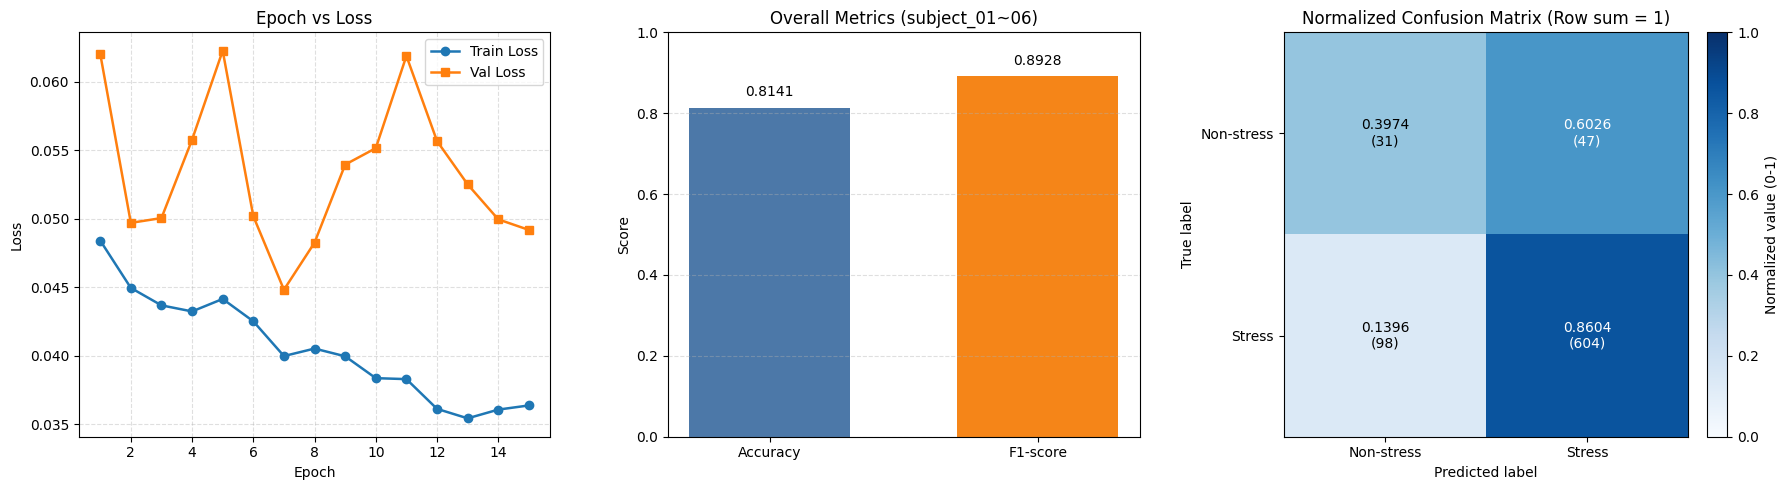

In [6]:
import numpy as np
import matplotlib.pyplot as plt

if len(all_true) == 0:
    raise RuntimeError('No aggregated samples to visualize.')

accuracy = accuracy_score(all_true, all_pred)
f1_val = f1_score(all_true, all_pred, zero_division=0)
cm = confusion_matrix(all_true, all_pred)
class_names = ['Non-stress', 'Stress']

cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Epoch / Loss graph (checkpoint history 사용)
history = ckpt.get('history', []) if isinstance(ckpt, dict) else []
if history:
    epochs = [int(h.get('epoch', i + 1)) for i, h in enumerate(history)]
    train_loss = [float(h.get('train_loss', np.nan)) for h in history]
    val_loss = [float(h.get('val_loss', np.nan)) for h in history]

    axes[0].plot(epochs, train_loss, marker='o', linewidth=1.8, label='Train Loss')
    axes[0].plot(epochs, val_loss, marker='s', linewidth=1.8, label='Val Loss')
    axes[0].set_title('Epoch vs Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, linestyle='--', alpha=0.4)
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'No history in checkpoint', ha='center', va='center', fontsize=11)
    axes[0].set_title('Epoch vs Loss')
    axes[0].set_xticks([])
    axes[0].set_yticks([])

# 2) F1-score / Accuracy bar graph
metrics = ['Accuracy', 'F1-score']
values = [accuracy, f1_val]
colors = ['#4C78A8', '#F58518']

bars = axes[1].bar(metrics, values, color=colors, width=0.6)
axes[1].set_ylim(0, 1)
axes[1].set_title('Overall Metrics (subject_01~06)')
axes[1].set_ylabel('Score')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for bar, v in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.02,
        f'{v:.4f}',
        ha='center',
        va='bottom',
        fontsize=10,
    )

# 3) Confusion matrix
im = axes[2].imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
axes[2].set_title('Normalized Confusion Matrix (Row sum = 1)')
axes[2].set_xlabel('Predicted label')
axes[2].set_ylabel('True label')
axes[2].set_xticks(np.arange(len(class_names)))
axes[2].set_yticks(np.arange(len(class_names)))
axes[2].set_xticklabels(class_names)
axes[2].set_yticklabels(class_names)

threshold = cm_norm.max() / 2 if cm_norm.size else 0.5
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[2].text(
            j,
            i,
            f'{cm_norm[i, j]:.4f}\n({cm[i, j]})',
            ha='center',
            va='center',
            color='white' if cm_norm[i, j] > threshold else 'black',
            fontsize=10,
        )

cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_label('Normalized value (0-1)')

plt.tight_layout()
plt.show()